In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [66]:
data = loadmat('cluster_dataset.mat')

In [67]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

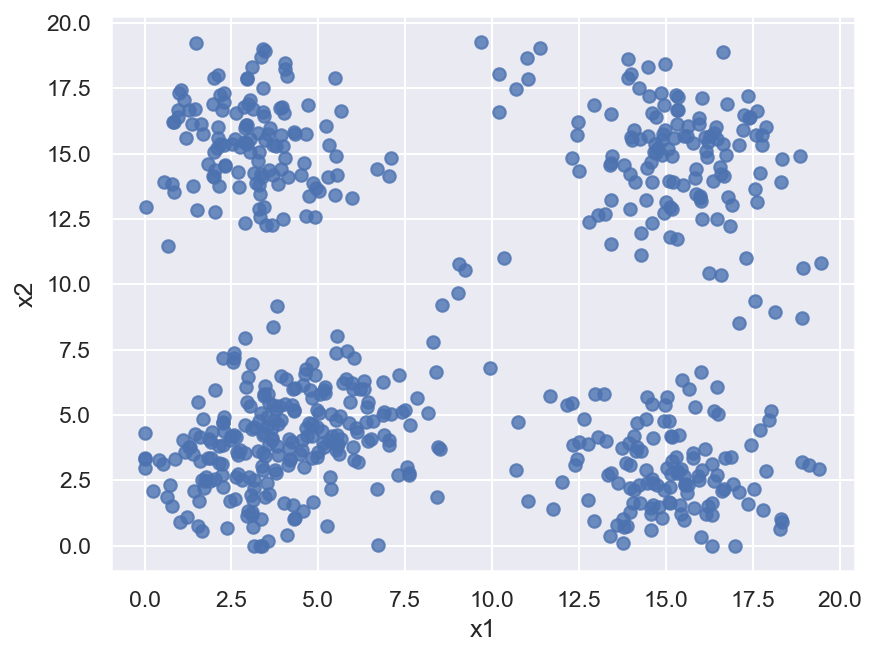

In [68]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [69]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [70]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
    n_samples = X.shape[0]
    indices = random.sample(range(n_samples), k)
    centers = [X[i] for i in indices]
    
    return centers

In [71]:
#向量欧氏距离计算
def distance(v1, v2):
    """
    输入：v1,v2:两个向量(ndarray)
    输出：欧式距离值
    提示：可使用np.sqrt, np.sum
    """
    distance = np.sqrt(np.sum((v1-v2)**2))
    return distance

In [72]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers:当前的聚类中心(list)
    输出：assignment:各个簇包含的样本(dict)
    提示：key为簇标号，value为该簇的样本列表
    """
    assignment = {}
    n_clusters = len(centers)
    for i in range(n_clusters):
        assignment[i] = []
    for sample in X:
        min_distance = np.inf
        min_cluster = None
        for j in range(n_clusters):
            dist = distance(sample, centers[j])
            if dist < min_distance:
                min_distance = dist
                min_cluster = j
        assignment[min_cluster].append(sample)
    return assignment

In [73]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：assignment:各个簇包含的样本(dict), centers:当前的聚类中心(list)
    输出：cost:代价函数值
    """
    total_distance = 0
    total_samples = 0
    for cluster_idx, samples in assignment.items():
        if len(samples) == 0:
            continue
        center = centers[cluster_idx]
        for sample in samples:
            total_distance += distance(sample, center)
        total_samples += len(samples)
    if total_samples == 0:
        return 0
    cost = total_distance / total_samples
    return cost

In [74]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment:各个簇包含的样本(dict), centers:当前的聚类中心(list)
    输出：new_centers:更新后的聚类中心(list), stop:是否满足停机条件(int)
    提示：当所有簇中心均不再改变时，stop=1
    """
    new_centers = []
    stop = 1
    # 按索引顺序遍历，确保new_centers与centers顺序一致
    for cluster_idx in range(len(centers)):
        samples = assignment.get(cluster_idx, [])
        if len(samples) == 0:
            new_centers.append(centers[cluster_idx])
            continue
        cluster_array = np.array(samples)
        new_center = np.mean(cluster_array, axis=0)
        new_centers.append(new_center)
        if not np.array_equal(new_center, centers[cluster_idx]):
            stop = 0
    return new_centers, stop

In [75]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    """
    输入：assignment:各个簇包含的样本(dict), centers:当前的聚类中心(list), epoch:当前迭代轮数
    功能：绘制当前的聚类结果图
    """
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [76]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k:聚类簇数(int), max_epoch:最大迭代轮数(int), plot:是否可视化(bool)
    输出：assignment:最终的聚类结果(dict), cost:最终的代价函数值
    """
    centers = init_centers(X, k)
    for epoch in range(max_epoch):
        assignment = cluster_assignment(X, centers)
        if plot:
            plot_clustering(assignment, centers, epoch)
        centers, stop = center_update(assignment, centers)
        if stop == 1:
            print(f"算法在第 {epoch+1} 轮收敛")
            break
    cost = cost_function(assignment, centers)
    return assignment, cost

In [77]:
max_epoch = 200 

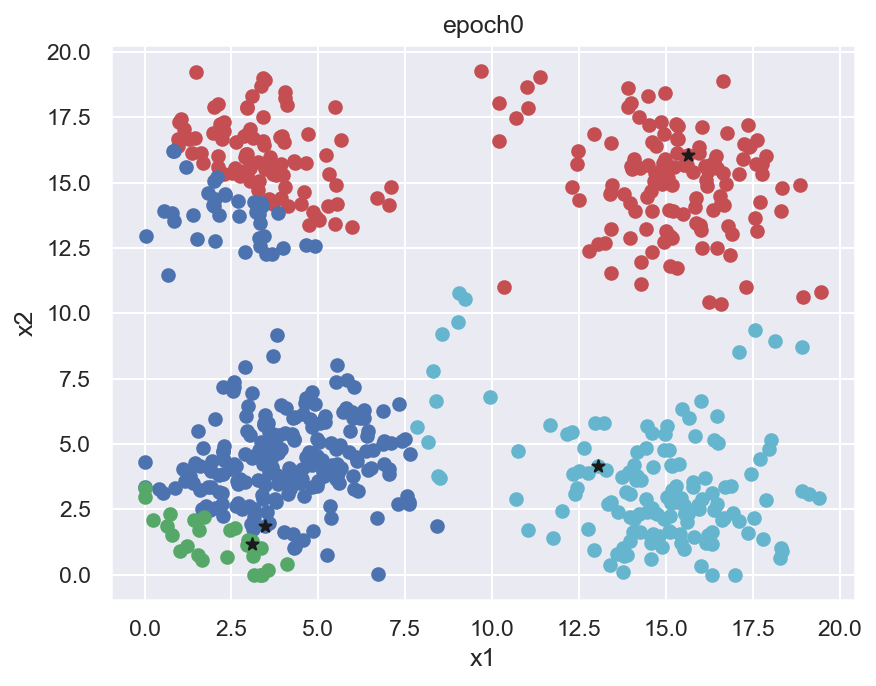

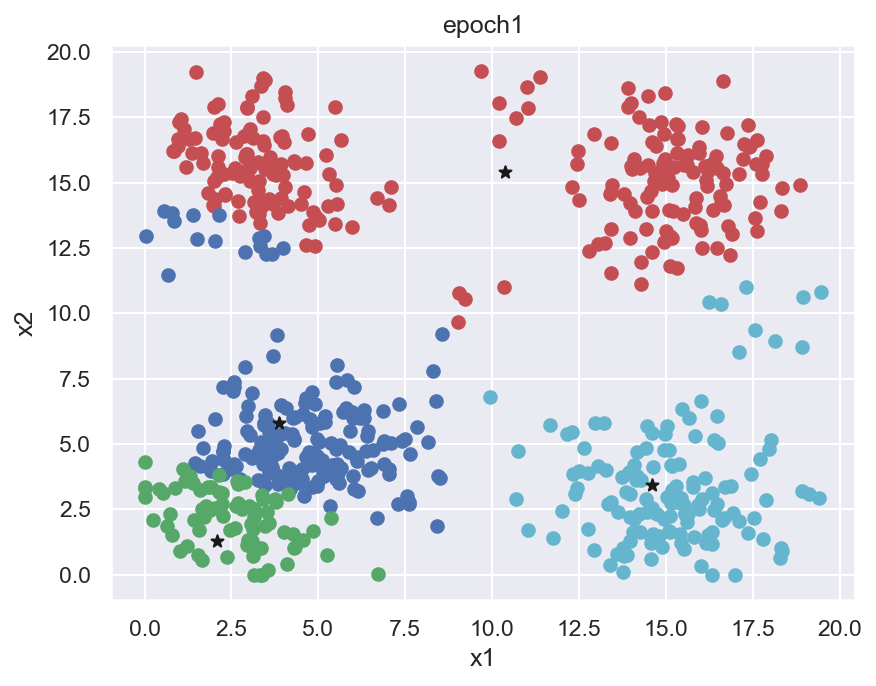

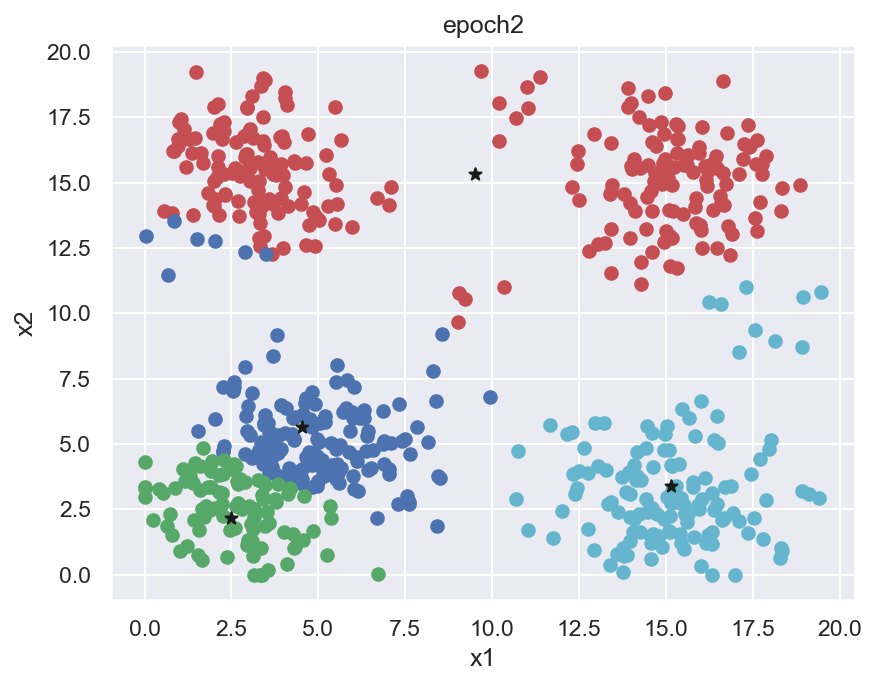

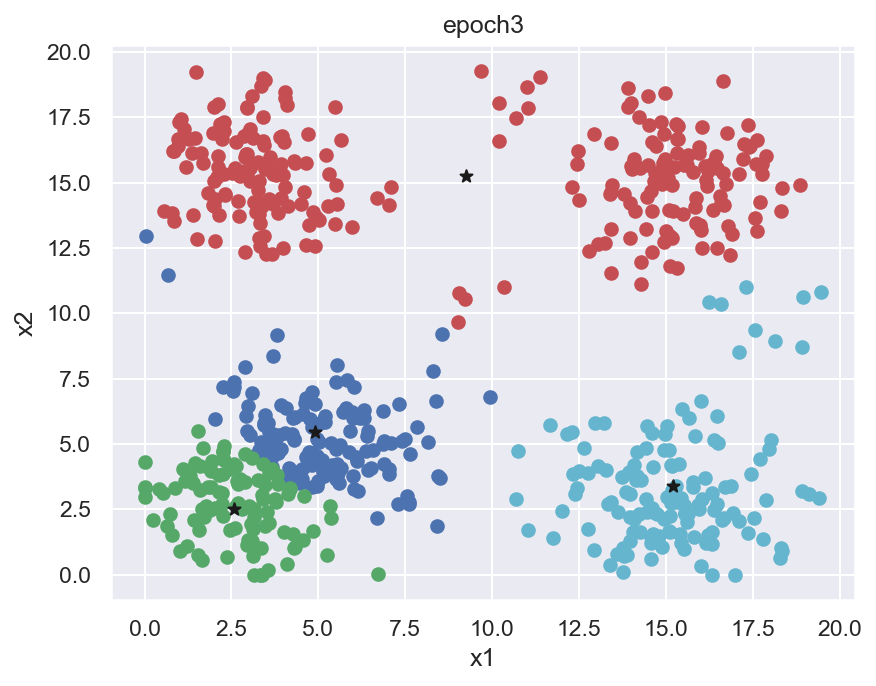

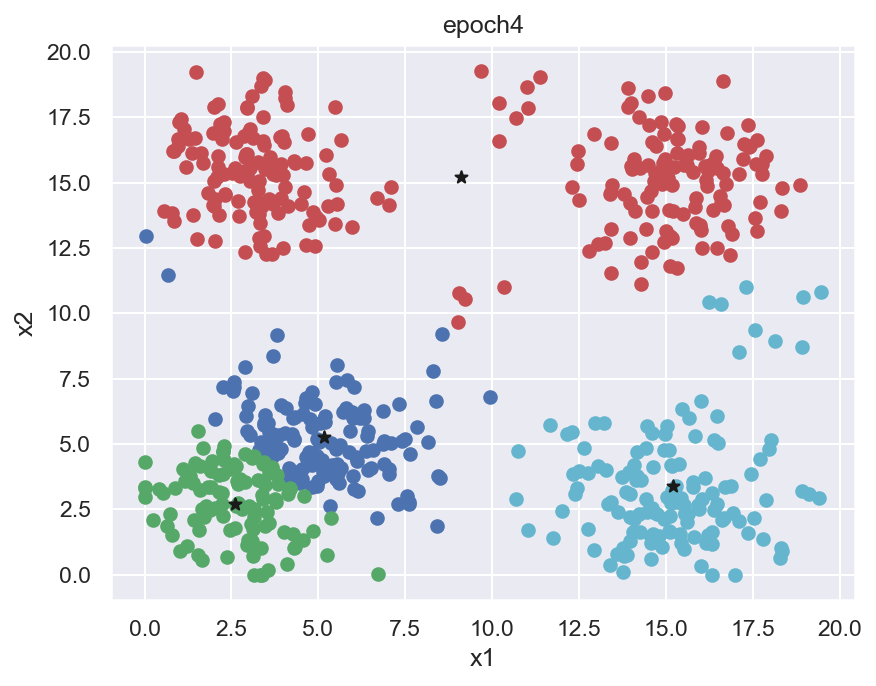

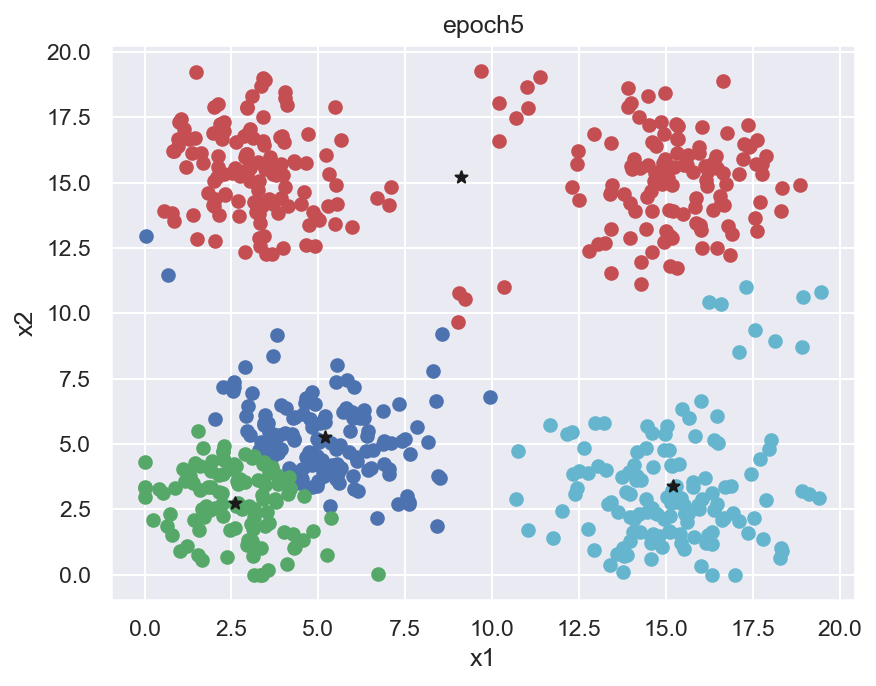

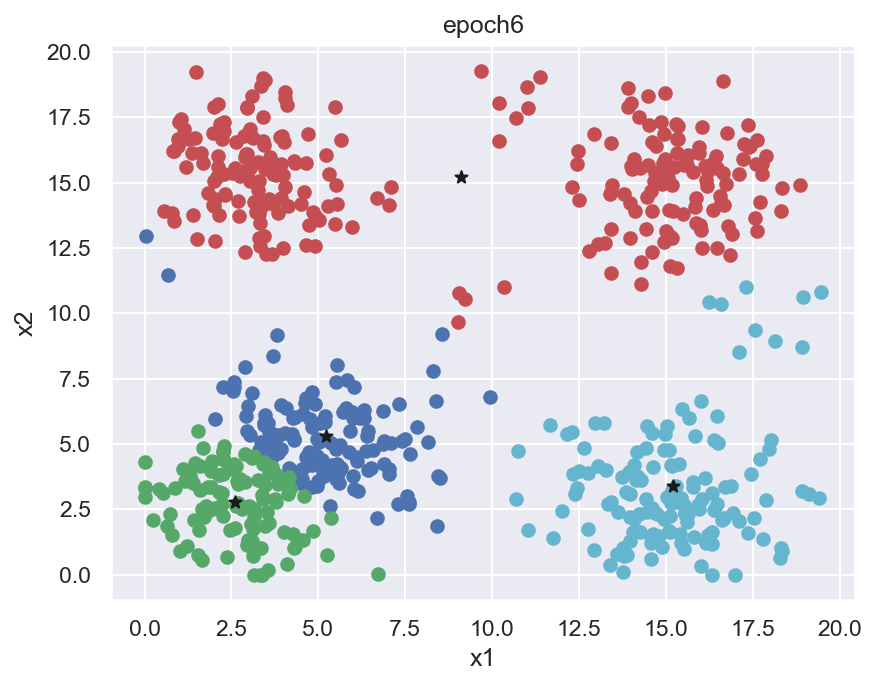

算法在第 7 轮收敛


In [78]:
assignment, _ = kmeans(X, k, max_epoch)

算法在第 2 轮收敛
算法在第 4 轮收敛
算法在第 5 轮收敛
算法在第 7 轮收敛
算法在第 8 轮收敛


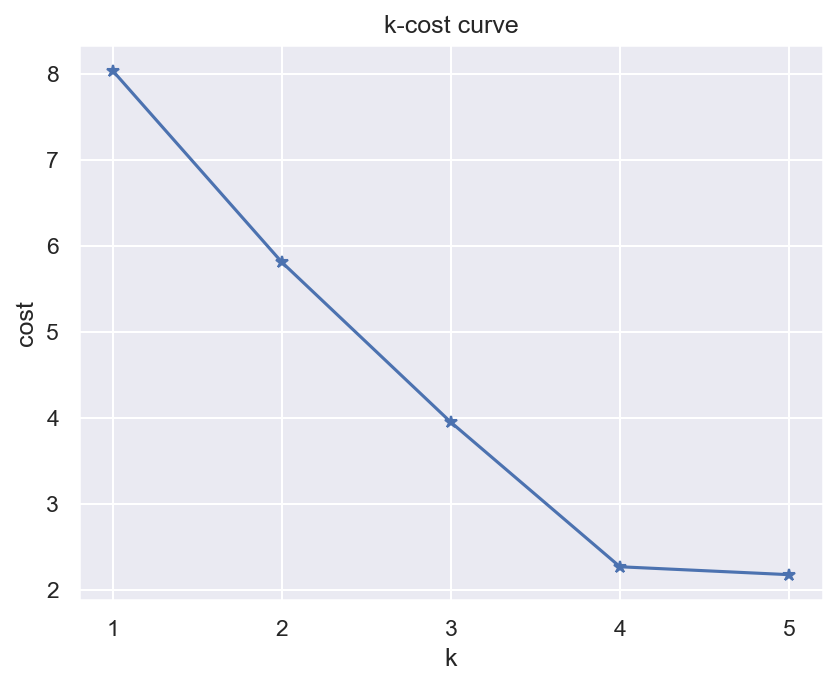

In [79]:
#绘制簇数-代价函数曲线
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch, False)
    Cost.append(cost)
plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()